# Overfitting — The Same Story in Three Model Families

Overfitting looks the same no matter which model family you use: as model complexity grows,
performance on the **training** data keeps improving while performance on **held-out** data peaks
and then degrades. The training score is therefore not a measure of quality at all — pushed far
enough, any sufficiently flexible model drives it to perfection by memorizing noise.

This notebook shows that one story three times, with a different complexity knob each time:

1. **Polynomial regression** — the polynomial degree
2. **K-nearest neighbors** — the number of neighbors (note: *smaller* K = more complex)
3. **Tree ensembles** — the maximum tree depth

## Learning objectives

- Identify overfitting from the divergence between a training and a held-out score curve
- Explain why a perfect training score is evidence of a problem, not of success
- Measure the *variance* of a model family by refitting it on repeated fresh samples
- Recognize that each family's complexity knob points in its own direction — larger depth is more
  complex, but larger K is *less*
- Locate the peak of the test curve as the principled place to set complexity

## Background

This notebook assumes a train/test split and the $R^2$ score, both used in
`U1-3_Regression-1_ModelCompare`, and the model families compared there. The bias–variance
decomposition that explains the shape of these curves is developed in section 1.1 where it is first
measured.

**Prerequisites:** `U1-3_Regression-1_ModelCompare` (the model families, $R^2$, train/test split)

**Dataset:** none — all data is generated in the notebook. Section 1 draws noisy samples from
$y = x^2$. Section 2 offers three targets for the KNN and tree experiments — a **line**, a
**parabola**, or a **sine wave** — selected by toggling which line is commented.

**References:** https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Polynomial regression

The cleanest demonstration, because the complexity knob is a single integer. A degree-$d$ polynomial

$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_d x^d$$

has $d+1$ free coefficients. Fit it to $n$ points and something mechanical happens: once
$d + 1 \ge n$, the polynomial has at least as many knobs as there are points to hit, so it can pass
through **every** one exactly — training error zero, $R^2 = 1$, regardless of how noisy the data is.

Here $n = 10$ and $d = 9$, so $d + 1 = n$ exactly. Watch what the curve does *between* and *beyond*
the points it threads.

coef: [-1.85766944e+00  2.27167004e+01 -1.14428160e+02  3.07611834e+02
 -4.78962326e+02  4.39720134e+02 -2.31697387e+02  6.47255530e+01
 -7.28865759e+00  4.68757598e-01]
error: 3.506938981881685e-20
r^2: 1.0


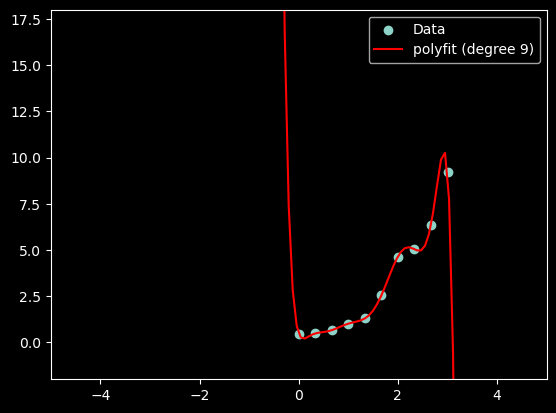

In [2]:
from sklearn.metrics import r2_score

nPts = 10

x = np.linspace(0, 3, nPts)
y = x**2 + np.random.normal(0, 0.5, nPts)

degree = 9
coef = np.polyfit(x, y, degree)
print("coef:", coef)

poly_function = np.poly1d(coef)
pred  = poly_function(x)
error = ((y-pred)**2).sum()
print("error:", error)
print("r^2:", r2_score(y,pred))

x_values = np.linspace(-4, 4, 100)
y_values = poly_function(x_values)

plt.scatter(x, y, label='Data')
plt.plot(x_values, y_values, label=f'polyfit (degree {degree})', color='red')

plt.xlim(-5,5);
plt.ylim(-2,18);
plt.legend();

The fit is perfect at the data and absurd everywhere else, swinging wildly between points and
diverging outside the range. A perfect training score bought a useless model.

### 1.1 Sweep degrees and repeat samples

The instability above is not bad luck with one sample — it is a property of the *procedure*. To show
that, refit each degree on several fresh noisy samples drawn from the same $y = x^2$ and look at the
spread of the fitted coefficients.

This is the **variance** term of the bias–variance decomposition. For squared-error loss, the
expected error at a point splits into three pieces:

$$\mathbb{E}\left[(y - \hat{f}(x))^2\right] =
\underbrace{\left(\mathbb{E}[\hat{f}(x)] - f(x)\right)^2}_{\text{bias}^2} +
\underbrace{\mathbb{E}\left[\left(\hat{f}(x) - \mathbb{E}[\hat{f}(x)]\right)^2\right]}_{\text{variance}} +
\underbrace{\sigma^2}_{\text{irreducible}}$$

**Bias** is how far the average fit sits from the truth — the error from a model too rigid to
represent the signal. **Variance** is how much the fit moves when the training sample changes.
$\sigma^2$ is the noise floor, which no model can beat.

Complexity trades one for the other: a low-degree polynomial has high bias and low variance, a
high-degree one the reverse. Overfitting is the variance term taking over. In the tables below, the
`std` row across the coefficient columns is that variance made visible — watch it explode with
degree.

In [3]:
nPts  = 10
nSamp = 10

data = []
for d in range(1,nPts):
    samp = []
    for i in range(nSamp):
        x = np.linspace(0, 3, nPts)
        y = x**2 + np.random.normal(0, 0.5, nPts)

        coef  = np.polyfit(x, y, d)
        poly_function = np.poly1d(coef)
        pred  = poly_function(x)
        error = ((y-pred)**2).sum()
        r2 = r2_score(y,pred)
        coef = np.append(coef, [error, r2])
        coef = np.flip(coef)
        
        samp.append(coef)
    # end
    data.append(samp)
# end

dfs = []
for i,d in enumerate(data):
    cols = ['r^2', 'error'] + list(range(i+2))
    df = pd.DataFrame(d, columns=cols)
    dfs.append(df)
    display(df.describe().iloc[1:3])
# end

,r^2,error,0,1
mean,0.924932,7.028632,-1.499234,3.079717
std,0.016076,1.363983,0.330103,0.172274


,r^2,error,0,1,2
mean,0.974363,2.345055,0.125897,-0.342185,1.099635
std,0.014328,1.413498,0.386719,0.739270,0.231044


,r^2,error,0,1,2,3
mean,0.981886,1.560249,0.039772,-0.422958,1.432482,-0.109527
std,0.013329,1.046190,0.323984,1.384794,1.218481,0.271413


,r^2,error,0,1,2,3,4
mean,0.985908,1.280420,-0.100016,0.700338,0.060968,0.465814,-0.076269
std,0.006756,0.619664,0.556518,3.110453,4.757671,2.443239,0.399794


,r^2,error,0,1,2,3,4,5
mean,0.994612,0.494990,0.116308,-0.570064,1.062181,0.489860,-0.277108,0.042305
std,0.004614,0.445936,0.413751,4.074542,10.700958,9.862002,3.710238,0.488442


,r^2,error,0,1,2,3,4,5,6
mean,0.989336,0.935451,0.040742,-2.528872,7.865005,-7.754675,4.455992,-1.278588,0.143976
std,0.009820,0.774730,0.563412,6.354574,22.237030,27.990879,16.268664,4.463264,0.467916


,r^2,error,0,1,2,3,4,5,6,7
mean,0.995080,0.441324,-0.049758,3.870342,-25.321535,58.678212,-59.270949,30.126723,-7.525099,0.734793
std,0.004365,0.371495,0.779996,6.523196,33.699738,69.087373,66.689789,32.925062,8.064209,0.777091


,r^2,error,0,1,2,3,4,5,6,7,8
mean,0.995970,0.346696,0.255760,-5.799806,37.708609,-88.739404,105.939040,-69.397791,25.479451,-4.927250,0.391207
std,0.005192,0.425320,0.479726,14.393905,89.513469,213.580195,264.159186,185.639646,74.409847,15.780508,1.369553


,r^2,error,0,1,2,3,4,5,6,7,8,9
mean,1.0,8.342308e-19,-0.093103,-2.944044,27.467841,-95.445341,176.982316,-183.029704,109.572029,-37.710152,6.921619,-0.524837
std,0.0,1.392454e-18,0.485635,93.767175,731.708470,2218.810295,3498.787387,3195.791769,1754.205296,570.482236,101.214709,7.542616


## 2. A shared noisy dataset for KNN and trees

Both remaining model families get the **same** data, so their overfitting curves are directly
comparable — any difference comes from the model, not from the sample.

Three targets are available here, one commented in at a time, each with its own noise level:

| Option | Target | Noise | Why run it |
|---|---|---|---|
| Line | $y = x$ | $\sigma = 0.5$ | The simplest signal, with the largest noise. Even KNN at $K=1$ has nothing to gain from flexibility, so the overfitting gap is almost entirely wasted variance. |
| Parabola | $y = 0.5x^2 - 2$ | $\sigma = 0.3$ | Curved but smooth. Moderate flexibility helps; too much still hurts. |
| Sine | $y = \sin(\pi x / 2)$ | $\sigma = 0.3$ | Oscillating over $x \in [-3, 3]$, so the model must track several turning points. The widest useful complexity range of the three. |

The overfitting story is the same in all three cases — training score climbing while the test score
peaks and falls — but the *location* of the test peak moves. A wigglier target justifies more
complexity before it starts fitting noise, which is exactly why the right complexity cannot be
chosen once and reused.

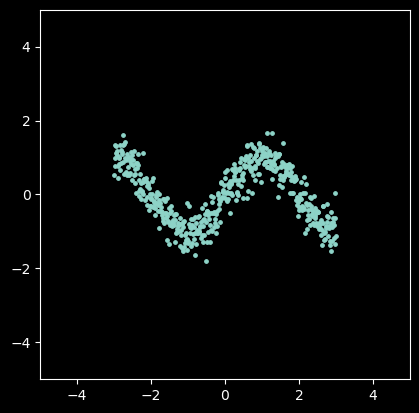

In [4]:
markersize = 6

nPts = 500

m = 1
b = 0

x = np.linspace(-3, 3, nPts)
#y = m*x + b + np.random.normal(0, 0.5, nPts)
#y = 0.5*x**2 - 2 + np.random.normal(0, 0.3, nPts)
y = np.sin(2*np.pi*x/4) + np.random.normal(0, 0.3, nPts)

X = x[:,np.newaxis]

plt.scatter(x, y, label='Data', s=markersize);
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.gca().set_aspect('equal')

### 2.1 Train/test split

The split is what makes the rest of the notebook possible: the training curve and the test curve
must come from disjoint data, or there is no gap to observe.

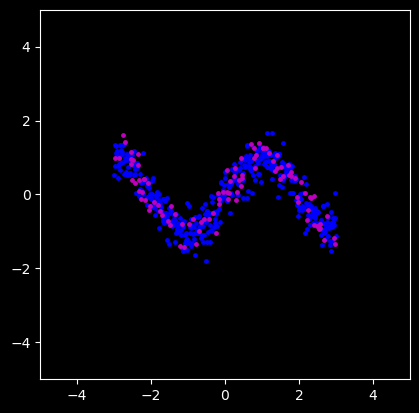

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

X_ext = np.linspace(-5, 5, 1000)[:,np.newaxis]

plt.scatter(X_train[:,0], y_train, label='Training Data', c='b', s=markersize);
plt.scatter(X_test[:,0], y_test, label='Testing Data', c='m', s=markersize);
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.gca().set_aspect('equal')

## 3. KNN — $R^2$ vs number of neighbors

K-nearest-neighbors predicts the average target of the $K$ closest training points:

$$\hat{f}(x) = \frac{1}{K} \sum_{i \in N_K(x)} y_i$$

Its complexity knob runs **backwards**. At $K = 1$ each prediction is the single nearest training
point, so on the training set every point predicts itself — train $R^2 = 1$, exactly the
memorization seen in section 1. As $K$ grows the model averages over more neighbors and smooths
out; at $K \to n$ it predicts the global mean and underfits completely.

So read the x-axis right to left for increasing complexity, and watch the **gap** between the two
curves rather than either curve alone.

The cell also offers both **weighting schemes**, one commented in at a time:

- `weights='uniform'` — every one of the $K$ neighbors contributes equally, as in the formula above.
- `weights='distance'` — neighbors are weighted by $1/d$, so closer points count for more:
  $\hat{f}(x) = \sum_i w_i y_i / \sum_i w_i$ with $w_i = 1/d(x, x_i)$.

The difference matters most at the memorization end. Under distance weighting a training point sits
at distance 0 from itself, so it receives infinite weight and predicts itself exactly — which means
train $R^2$ stays pinned at 1 for **every** $K$, not just $K = 1$. The training curve goes flat and
only the test curve carries information. Run both and compare the two plots; it is a clean
demonstration that a training score can be rendered completely uninformative by a modelling choice.

In [6]:
from sklearn.neighbors import KNeighborsRegressor

maxNeigh = 100

r2_train = []
r2_test  = []
for i in range(1,maxNeigh+1):
    model = KNeighborsRegressor(n_neighbors=i,weights='uniform')
    #model = KNeighborsRegressor(n_neighbors=i,weights='distance')
    model.fit(X_train,y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)
    
    r2_train.append( r2_score(y_train,y_train_pred) )
    r2_test.append( r2_score(y_test,y_test_pred) )
# end

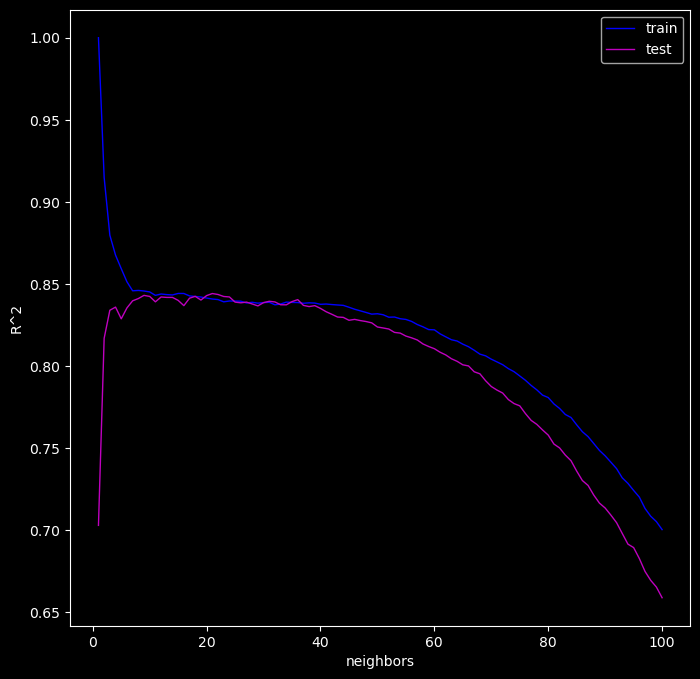

In [7]:
plt.figure(figsize=(8,8))

plt.plot(np.arange(maxNeigh)+1,
             r2_train,
             'b',
             label="train",
             linewidth=1)
plt.plot(np.arange(maxNeigh)+1,
             r2_test,
             'm',
             label="test",
             linewidth=1)
plt.xlabel("neighbors");
plt.ylabel("R^2");
plt.legend()

## 4. Trees and ensembles — $R^2$ vs max depth

Third family, and here the knob points the usual way: a tree of depth $d$ can carve the input into
at most $2^d$ regions, so deeper means more flexible. Left unlimited, a tree splits until every leaf
is pure and memorizes the training set outright.

Three models are available, one commented in at a time, and running all three is the point of the
section — they differ precisely in how they handle the variance that depth introduces:

| Option | What it does | Expected shape |
|---|---|---|
| `DecisionTreeRegressor` | One tree. | The starkest curve. Train $R^2$ climbs to 1 and stays; the test curve peaks early and then sags as depth buys pure leaves on noise. |
| `RandomForestRegressor` | Many trees on bootstrap samples, averaged. | Averaging is variance reduction in the sense of section 1.1, so the test curve should sag far less at high depth. Depth becomes close to harmless. |
| `GradientBoostingRegressor` | Shallow trees fit in sequence to each other's residuals. | Different mechanism entirely — depth controls the *complexity of each correction*, so deep trees can overfit quickly even though the ensemble is large. |

Comparing the single tree against the forest is the cleanest demonstration in the notebook that
**ensembling attacks the variance term specifically**: same family, same depths, same data, and a
visibly flatter test curve.

In [8]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

max_max_depth = 40

r2_train = []
r2_test  = []
for i in range(1,max_max_depth+1):
    #model = DecisionTreeRegressor(max_depth=i)
    model = RandomForestRegressor(max_depth=i)
    #model = GradientBoostingRegressor(max_depth=i)
    model.fit(X_train,y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)
    
    r2_train.append( r2_score(y_train,y_train_pred) )
    r2_test.append( r2_score(y_test,y_test_pred) )
# end

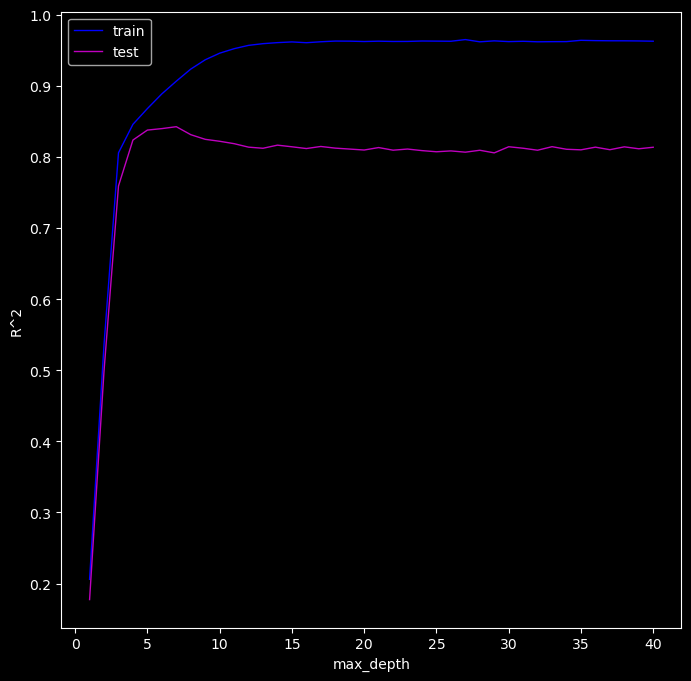

In [9]:
plt.figure(figsize=(8,8))

plt.plot(np.arange(max_max_depth)+1,
             r2_train,
             'b',
             label="train",
             linewidth=1)
plt.plot(np.arange(max_max_depth)+1,
             r2_test,
             'm',
             label="test",
             linewidth=1)
plt.xlabel("max_depth");
plt.ylabel("R^2");
plt.legend()

## 5. Review

- **Overfitting is a divergence, not a bad score.** In all three panels the training curve keeps
  climbing while the test curve peaks and falls away. The gap between them is the signature.
- **A perfect training score is a warning.** A degree-9 polynomial through 10 points and KNN at
  $K=1$ both achieve $R^2 = 1$ on training data by memorizing it, noise included.
- **The bias–variance decomposition explains the shape:**
  $\mathbb{E}[(y-\hat{f})^2] = \text{bias}^2 + \text{variance} + \sigma^2$. Simple models carry
  bias, flexible models carry variance, and $\sigma^2$ is a floor no model can beat.
- **Variance is measurable.** Refitting the same degree on fresh samples and watching the
  coefficients' spread explode is that term made concrete.
- **Each family's knob has its own direction.** Depth and degree increase complexity; the number of
  neighbors *decreases* it.
- **Averaging reduces variance**, which is why a random forest degrades far less gracefully with
  depth than a single tree.
- **The peak of the test curve is where complexity should be set.** Doing that by eye on one split
  is fragile, which is what `U1-3_Regression-3_CrossValidation` and `-4_GridSearchCV` fix.